In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
%matplotlib inline


class BaseDataProvider(object):
    channels = 1
    n_class = 2

    def __init__(self, a_min=None, a_max=None):
        self.a_min = a_min if a_min is not None else -np.inf
        self.a_max = a_max if a_max is not None else np.inf

    def _load_data_and_label(self):
        data, label = self._next_data()

        train_data = self._process_data(data)
        labels = self._process_labels(label)

        train_data, labels = self._post_process(train_data, labels)

        nx = train_data.shape[1]
        ny = train_data.shape[0]

        return train_data.reshape(1, ny, nx, self.channels), labels.reshape(1, ny, nx, self.n_class),

    def _process_labels(self, label):
        if self.n_class == 2:
            nx = label.shape[1]
            ny = label.shape[0]
            labels = np.zeros((ny, nx, self.n_class), dtype=np.float32)

            # It is the responsibility of the child class to make sure that the label
            # is a boolean array, but we a chech here just in case.
            if label.dtype != 'bool':
                label = label.astype(bool)

            labels[..., 1] = label
            labels[..., 0] = ~label
            return labels

        return label

    def _process_data(self, data):
        # normalization
        data = np.clip(np.fabs(data), self.a_min, self.a_max)
        data -= np.amin(data)

        if np.amax(data) != 0:
            data /= np.amax(data)

        return data

    def _post_process(self, data, labels):
        """
        Post processing hook that can be used for data augmentation
        :param data: the data array
        :param labels: the label array
        """
        return data, labels

    def __call__(self, n):
        train_data, labels = self._load_data_and_label()
        nx = train_data.shape[1]
        ny = train_data.shape[2]

        X = np.zeros((n, nx, ny, self.channels))
        Y = np.zeros((n, nx, ny, self.n_class))

        X[0] = train_data
        Y[0] = labels
        for i in range(1, n):
            train_data, labels = self._load_data_and_label()
            X[i] = train_data
            Y[i] = labels

        return X, Y

class GrayScaleDataProvider(BaseDataProvider):
    channels = 1
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(GrayScaleDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class=3

    def _next_data(self):
        return create_image_and_label(self.nx, self.ny, **self.kwargs)

class RgbDataProvider(BaseDataProvider):
    channels = 3
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(RgbDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs
        rect = kwargs.get("rectangles", False)
        if rect:
            self.n_class=3


    def _next_data(self):
        data, label = create_image_and_label(self.nx, self.ny, **self.kwargs)
        return to_rgb(data), label

def create_image_and_label(nx,ny, cnt = 10, r_min = 5, r_max = 50, border = 92, sigma = 20, rectangles=False):


    image = np.ones((nx, ny, 1))
    label = np.zeros((nx, ny, 3), dtype=bool)
    mask = np.zeros((nx, ny), dtype=bool)
    for _ in range(cnt):
        a = np.random.randint(border, nx-border)
        b = np.random.randint(border, ny-border)
        r = np.random.randint(r_min, r_max)
        h = np.random.randint(1,255)

        y,x = np.ogrid[-a:nx-a, -b:ny-b]
        m = x*x + y*y <= r*r
        mask = np.logical_or(mask, m)

        image[m] = h

    label[mask, 1] = 1

    if rectangles:
        mask = np.zeros((nx, ny), dtype=bool)
        for _ in range(cnt//2):
            a = np.random.randint(nx)
            b = np.random.randint(ny)
            r =  np.random.randint(r_min, r_max)
            h = np.random.randint(1,255)

            m = np.zeros((nx, ny), dtype=bool)
            m[a:a+r, b:b+r] = True
            mask = np.logical_or(mask, m)
            image[m] = h

        label[mask, 2] = 1

        label[..., 0] = ~(np.logical_or(label[...,1], label[...,2]))

    image += np.random.normal(scale=sigma, size=image.shape)
    image -= np.amin(image)
    image /= np.amax(image)

    if rectangles:
        return image, label
    else:
        return image, label[..., 1]




def to_rgb(img):
    img = img.reshape(img.shape[0], img.shape[1])
    img[np.isnan(img)] = 0
    img -= np.amin(img)
    img /= np.amax(img)
    blue = np.clip(4*(0.75-img), 0, 1)
    red  = np.clip(4*(img-0.25), 0, 1)
    green= np.clip(4*np.fabs(img-0.5)-1., 0, 1)
    rgb = np.stack((red, green, blue), axis=2)
    return rgb


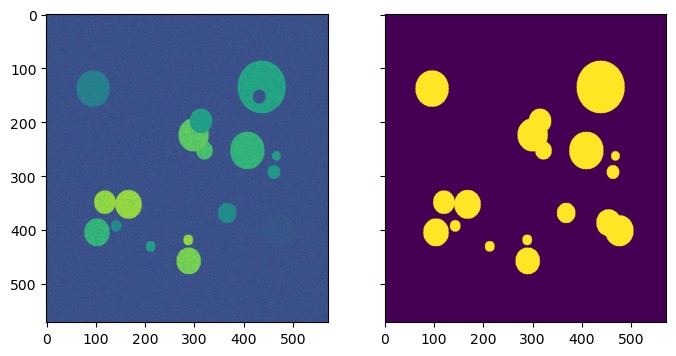

In [2]:
import matplotlib.pyplot as plt

nx = 572
ny = 572
generator = GrayScaleDataProvider(nx, ny, cnt=20)
x_test, y_test = generator(1)

fig, ax = plt.subplots(1, 2, sharey=True, figsize=(8, 4))
ax[0].imshow(x_test[0, ..., 0], aspect="auto")
ax[1].imshow(y_test[0, ..., 1], aspect="auto")

plt.show()

X shape: (2000, 256, 256, 1), Y shape: (2000, 256, 256, 1)
Train samples: 1400, Val: 300, Test: 300
UNet(
  (encoder): ModuleList(
    (0): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): DoubleConv(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True,

Epoch 1/50 [Train]: 100%|████████████████████████████████████████████████████████████| 175/175 [52:50<00:00, 18.12s/it]


Epoch 1: Train Loss: 0.1936, Train IoU: 0.9229, Train Dice: 0.9568 | Val Loss: 0.1448, Val IoU: 0.9449, Val Dice: 0.9704


Epoch 2/50 [Train]: 100%|████████████████████████████████████████████████████████████| 175/175 [53:18<00:00, 18.28s/it]


Epoch 2: Train Loss: 0.1193, Train IoU: 0.9551, Train Dice: 0.9761 | Val Loss: 0.0904, Val IoU: 0.9712, Val Dice: 0.9849


...

Epoch 48: Train Loss: 0.0073, Train IoU: 0.9948, Train Dice: 0.9974 | Val Loss: 0.0350, Val IoU: 0.9869, Val Dice: 0.9932


Epoch 49/50 [Train]: 100%|███████████████████████████████████████████████████████████| 175/175 [53:06<00:00, 18.21s/it]


Epoch 49: Train Loss: 0.0081, Train IoU: 0.9942, Train Dice: 0.9971 | Val Loss: 0.0466, Val IoU: 0.9734, Val Dice: 0.9862


Epoch 50/50 [Train]: 100%|███████████████████████████████████████████████████████████| 175/175 [54:39<00:00, 18.74s/it]


Epoch 50: Train Loss: 0.0153, Train IoU: 0.9898, Train Dice: 0.9948 | Val Loss: 0.0316, Val IoU: 0.9870, Val Dice: 0.9932


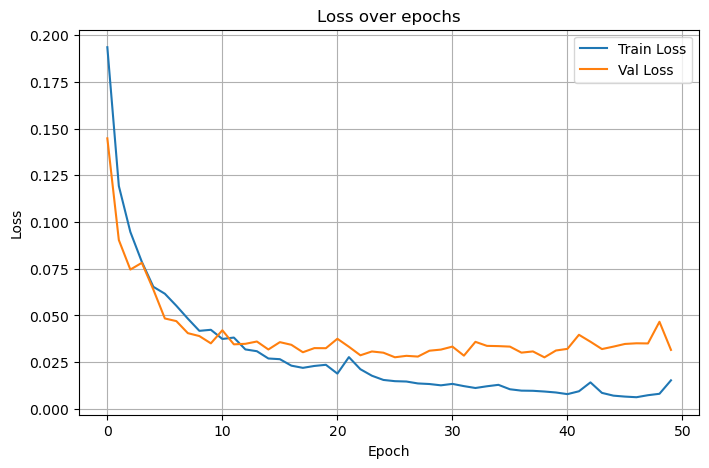

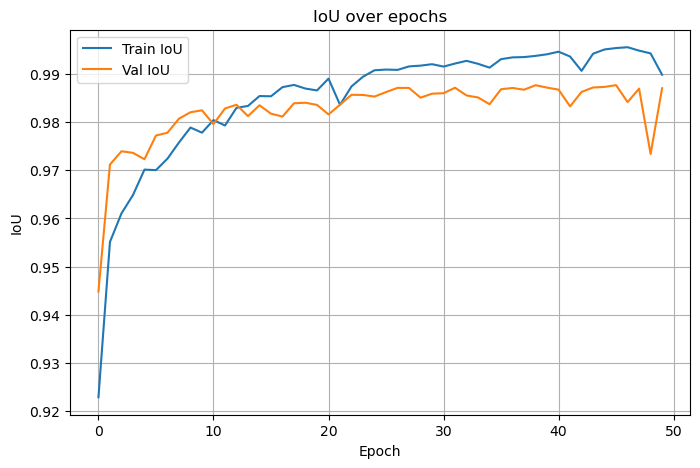

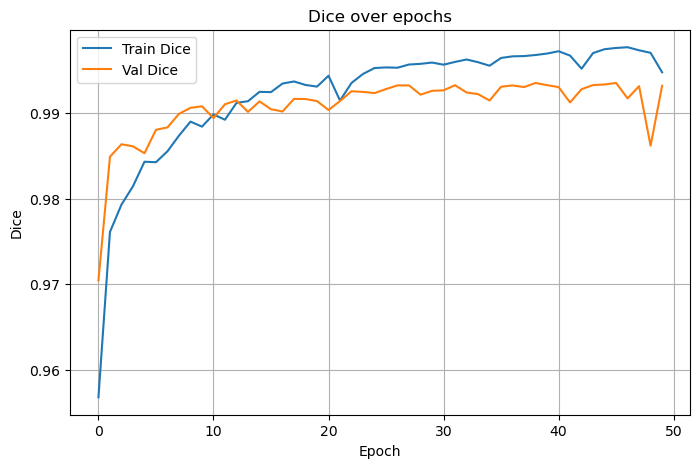


Test results: Loss = 0.0464, IoU = 0.9804, Dice = 0.9898


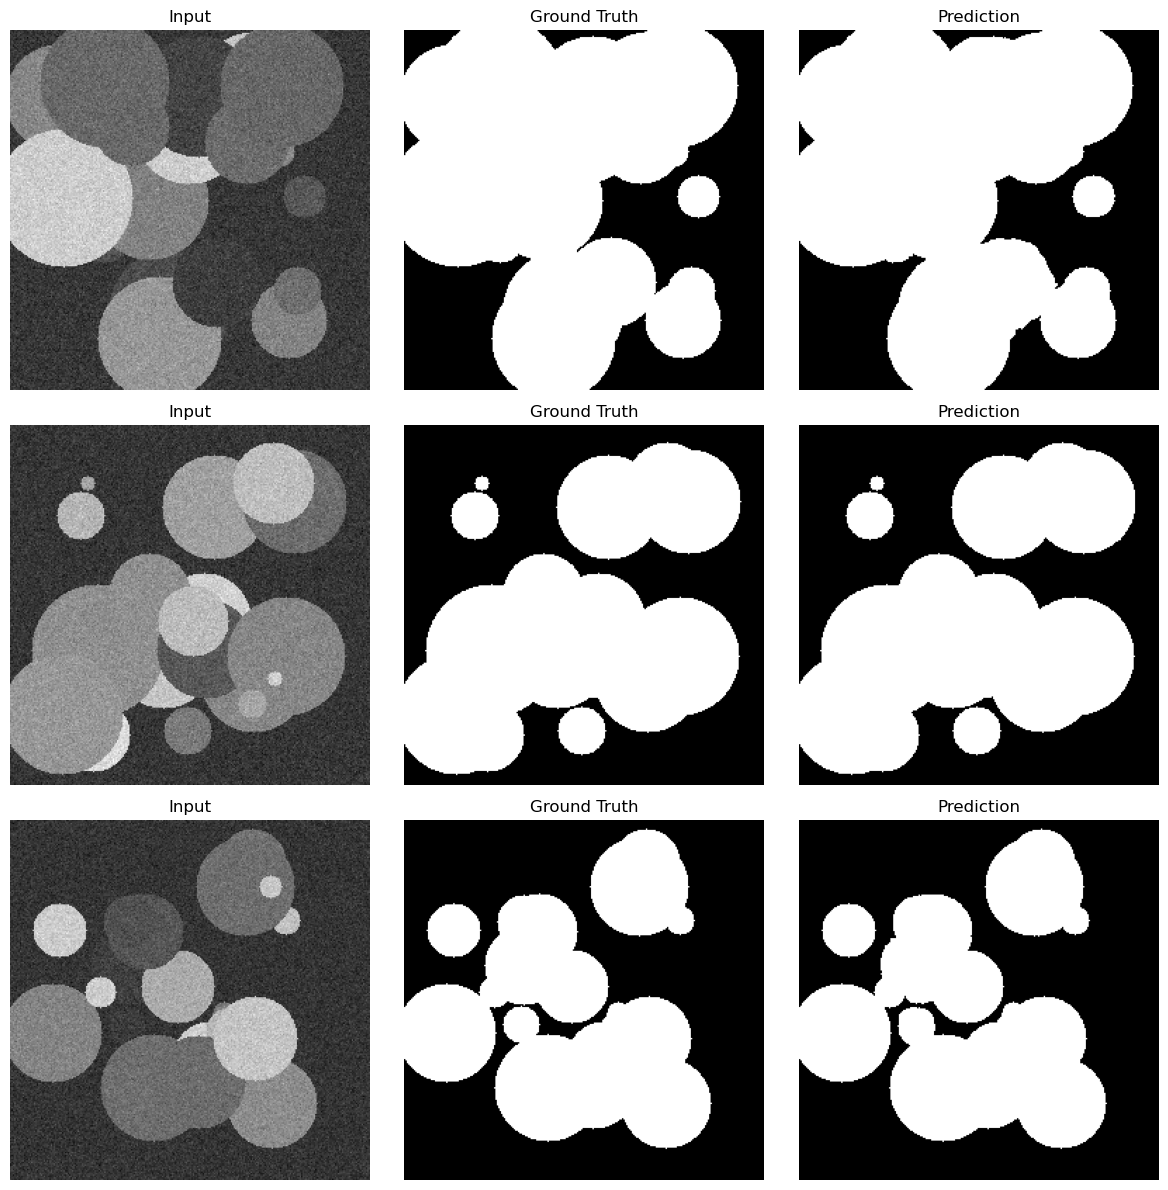

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

# 1. Генератор данных
class BaseDataProvider(object):
    channels = 1
    n_class = 2

    def __init__(self, a_min=None, a_max=None):
        self.a_min = a_min if a_min is not None else -np.inf
        self.a_max = a_max if a_min is not None else np.inf

    def _load_data_and_label(self):
        data, label = self._next_data()
        train_data = self._process_data(data)
        labels = self._process_labels(label)
        train_data, labels = self._post_process(train_data, labels)
        nx = train_data.shape[1]
        ny = train_data.shape[0]
        return train_data.reshape(1, ny, nx, self.channels), labels.reshape(1, ny, nx, self.n_class)

    def _process_labels(self, label):
        if self.n_class == 2:
            nx = label.shape[1]
            ny = label.shape[0]
            labels = np.zeros((ny, nx, self.n_class), dtype=np.float32)
            if label.dtype != 'bool':
                label = label.astype(bool)
            labels[..., 1] = label
            labels[..., 0] = ~label
            return labels
        return label

    def _process_data(self, data):
        data = np.clip(np.fabs(data), self.a_min, self.a_max)
        data -= np.amin(data)
        if np.amax(data) != 0:
            data /= np.amax(data)
        return data

    def _post_process(self, data, labels):
        return data, labels

    def __call__(self, n):
        train_data, labels = self._load_data_and_label()
        nx = train_data.shape[1]
        ny = train_data.shape[2]
        X = np.zeros((n, nx, ny, self.channels))
        Y = np.zeros((n, nx, ny, self.n_class))
        X[0] = train_data
        Y[0] = labels
        for i in range(1, n):
            train_data, labels = self._load_data_and_label()
            X[i] = train_data
            Y[i] = labels
        return X, Y

class GrayScaleDataProvider(BaseDataProvider):
    channels = 1
    n_class = 2

    def __init__(self, nx, ny, **kwargs):
        super(GrayScaleDataProvider, self).__init__()
        self.nx = nx
        self.ny = ny
        self.kwargs = kwargs

    def _next_data(self):
        return create_image_and_label(self.nx, self.ny, **self.kwargs)

def create_image_and_label(nx, ny, cnt=10, r_min=5, r_max=50, border=92, sigma=20, rectangles=False):
    image = np.ones((nx, ny, 1))
    label = np.zeros((nx, ny, 3), dtype=bool)
    mask = np.zeros((nx, ny), dtype=bool)
    for _ in range(cnt):
        a = np.random.randint(border, nx-border)
        b = np.random.randint(border, ny-border)
        r = np.random.randint(r_min, r_max)
        h = np.random.randint(1, 255)
        y, x = np.ogrid[-a:nx-a, -b:ny-b]
        m = x*x + y*y <= r*r
        mask = np.logical_or(mask, m)
        image[m] = h
    label[mask, 1] = 1
    if rectangles:
        mask = np.zeros((nx, ny), dtype=bool)
        for _ in range(cnt//2):
            a = np.random.randint(nx)
            b = np.random.randint(ny)
            r = np.random.randint(r_min, r_max)
            h = np.random.randint(1, 255)
            m = np.zeros((nx, ny), dtype=bool)
            m[a:a+r, b:b+r] = True
            mask = np.logical_or(mask, m)
            image[m] = h
        label[mask, 2] = 1
        label[..., 0] = ~(np.logical_or(label[...,1], label[...,2]))
    image += np.random.normal(scale=sigma, size=image.shape)
    image -= np.amin(image)
    image /= np.amax(image)
    if rectangles:
        return image, label
    else:
        return image, label[..., 1]


# 2. Генерация фиксированного набора данных

IMG_SIZE = 256
NUM_SAMPLES = 2000

generator = GrayScaleDataProvider(IMG_SIZE, IMG_SIZE, cnt=20, r_min=5, r_max=50, border=30, sigma=20)
X_np, Y_np = generator(NUM_SAMPLES)      # X: (n, nx, ny, 1), Y: (n, nx, ny, 2)
Y_np = Y_np[..., 1]                      # берём только канал кружочков
Y_np = np.expand_dims(Y_np, axis=-1)     # (n, nx, ny, 1)

print(f"X shape: {X_np.shape}, Y shape: {Y_np.shape}")


# 3. Разделение на train/val/test

X_train, X_temp, Y_train, Y_temp = train_test_split(X_np, Y_np, test_size=0.3, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

# Преобразуем в тензоры PyTorch (NCHW формат)
X_train = torch.from_numpy(X_train).permute(0, 3, 1, 2).float()
Y_train = torch.from_numpy(Y_train).permute(0, 3, 1, 2).float()
X_val   = torch.from_numpy(X_val).permute(0, 3, 1, 2).float()
Y_val   = torch.from_numpy(Y_val).permute(0, 3, 1, 2).float()
X_test  = torch.from_numpy(X_test).permute(0, 3, 1, 2).float()
Y_test  = torch.from_numpy(Y_test).permute(0, 3, 1, 2).float()

train_dataset = TensorDataset(X_train, Y_train)
val_dataset   = TensorDataset(X_val, Y_val)
test_dataset  = TensorDataset(X_test, Y_test)

batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train samples: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


# 4. Определение U-Net на PyTorch

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.encoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder path
        for feature in features:
            self.encoder.append(DoubleConv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = DoubleConv(features[-1], features[-1]*2)

        # Decoder path
        self.upconvs = nn.ModuleList()
        self.decoder = nn.ModuleList()
        for feature in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.decoder.append(DoubleConv(feature*2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        skip_connections = []
        for enc in self.encoder:
            x = enc(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)

        skip_connections = skip_connections[::-1]
        for idx, (upconv, dec) in enumerate(zip(self.upconvs, self.decoder)):
            x = upconv(x)
            skip = skip_connections[idx]
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:], mode='bilinear', align_corners=False)
            x = torch.cat((skip, x), dim=1)
            x = dec(x)

        x = self.final_conv(x)
        return self.sigmoid(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet(in_channels=1, out_channels=1).to(device)
print(model)


# 5. Метрики и функция потерь

def iou_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    intersection = (y_true * y_pred).sum(dim=(2,3))
    union = y_true.sum(dim=(2,3)) + y_pred.sum(dim=(2,3)) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean()

def dice_score(y_true, y_pred, threshold=0.5):
    y_pred = (y_pred > threshold).float()
    intersection = (y_true * y_pred).sum(dim=(2,3))
    dice = (2. * intersection + 1e-6) / (y_true.sum(dim=(2,3)) + y_pred.sum(dim=(2,3)) + 1e-6)
    return dice.mean()

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)


# 6. Цикл обучения

num_epochs = 50
train_losses, val_losses = [], []
train_ious, val_ious = [], []
train_dices, val_dices = [], []

for epoch in range(num_epochs):
    # Training
    model.train()
    epoch_loss = 0.0
    epoch_iou = 0.0
    epoch_dice = 0.0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * images.size(0)
        epoch_iou += iou_score(masks, outputs).item() * images.size(0)
        epoch_dice += dice_score(masks, outputs).item() * images.size(0)

    epoch_loss /= len(train_loader.dataset)
    epoch_iou /= len(train_loader.dataset)
    epoch_dice /= len(train_loader.dataset)
    train_losses.append(epoch_loss)
    train_ious.append(epoch_iou)
    train_dices.append(epoch_dice)

    # Validation
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_dice = 0.0
    with torch.no_grad():
        for images, masks in val_loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            val_loss += loss.item() * images.size(0)
            val_iou += iou_score(masks, outputs).item() * images.size(0)
            val_dice += dice_score(masks, outputs).item() * images.size(0)
    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)
    val_dice /= len(val_loader.dataset)
    val_losses.append(val_loss)
    val_ious.append(val_iou)
    val_dices.append(val_dice)

    print(f"Epoch {epoch+1}: Train Loss: {epoch_loss:.4f}, Train IoU: {epoch_iou:.4f}, Train Dice: {epoch_dice:.4f} | Val Loss: {val_loss:.4f}, Val IoU: {val_iou:.4f}, Val Dice: {val_dice:.4f}")


# 7. Построение графиков

def plot_curves(train_vals, val_vals, metric_name, ylabel):
    plt.figure(figsize=(8,5))
    plt.plot(train_vals, label=f'Train {metric_name}')
    plt.plot(val_vals, label=f'Val {metric_name}')
    plt.xlabel('Epoch')
    plt.ylabel(ylabel)
    plt.title(f'{metric_name} over epochs')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_curves(train_losses, val_losses, 'Loss', 'Loss')
plot_curves(train_ious, val_ious, 'IoU', 'IoU')
plot_curves(train_dices, val_dices, 'Dice', 'Dice')


# 8. Оценка на тестовой выборке

model.eval()
test_loss = 0.0
test_iou = 0.0
test_dice = 0.0
with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        test_loss += criterion(outputs, masks).item() * images.size(0)
        test_iou += iou_score(masks, outputs).item() * images.size(0)
        test_dice += dice_score(masks, outputs).item() * images.size(0)
test_loss /= len(test_loader.dataset)
test_iou /= len(test_loader.dataset)
test_dice /= len(test_loader.dataset)

print(f"\nTest results: Loss = {test_loss:.4f}, IoU = {test_iou:.4f}, Dice = {test_dice:.4f}")


# 9. Визуализация предсказаний

def visualize_predictions(model, dataset, device, num_samples=3):
    model.eval()
    indices = np.random.choice(len(dataset), num_samples, replace=False)
    plt.figure(figsize=(12, 4*num_samples))
    for i, idx in enumerate(indices):
        img, mask = dataset[idx]
        img = img.unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(img).cpu().squeeze(0).squeeze(0).numpy()
        img_np = img.cpu().squeeze(0).squeeze(0).numpy()
        mask_np = mask.squeeze(0).numpy()
        # входное изображение
        plt.subplot(num_samples, 3, i*3+1)
        plt.imshow(img_np, cmap='gray')
        plt.title('Input')
        plt.axis('off')
        # истинная маска
        plt.subplot(num_samples, 3, i*3+2)
        plt.imshow(mask_np, cmap='gray')
        plt.title('Ground Truth')
        plt.axis('off')
        # предсказание
        plt.subplot(num_samples, 3, i*3+3)
        plt.imshow(pred > 0.5, cmap='gray')
        plt.title('Prediction')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(model, val_dataset, device)

В этом ноутбуке была детально разобрана задача семантической сегментации изображений: от генерации синтетического набора данных до создания и обучения модели нейронной сети.
Ключевые этапы работы:
1.	Генерация синтетического набора данных: С помощью Python была создана программа, генерирующая изображения с кругами разного размера и положения на случайном фоне. Это позволило получить неограниченное количество размеченных данных для обучения, где в качестве целевых масок использовались True для пикселей круга и False для фона.
2.	Создание модели архитектуры U-Net: Была разработана и реализована нейронная сеть, архитектура которой хорошо зарекомендовала себя для задач биомедицинской сегментации изображений. Структура U-Net включает в себя сужающуюся часть для захвата контекста ("кодировщик") и расширяющуюся часть для точной локализации ("декодер").
3.	Обучение и оценка модели: Сеть была обучена на сгенерированных данных. В процессе обучения отслеживалась динамика изменения функции потерь с использованием визуализаций. Итоговая точность предсказаний модели также была наглядно показана и позволила сделать вывод о высоком качестве её работы на тестовых примерах.

Итоги и основные выводы
Анализ проделанной работы позволяет сформулировать несколько ключевых выводов:
•	Эффективность синтетических данных: Продемонстрировано, что создание синтетического набора данных — это мощный и практичный подход в ситуациях, когда реальные размеченные данные получить трудоемко или невозможно. Это позволяет быстро создавать размеченные выборки практически неограниченного размера.
•	Мощь архитектуры U-Net: U-Net отлично справляется с задачей семантической сегментации, даже для геометрически простых форм. Её способность точно выделять границы объектов (в данном случае, кругов) делает её идеальным выбором для подобных задач.
•	Рабочий процесс решения задачи: Ноутбук служит отличным шаблоном для решения задач сегментации, наглядно объединяя в себе все этапы: от формирования данных, построения и обучения модели до визуализации конечного результата.
•	Полученные результаты открывают возможности для дальнейших экспериментов. Например, модель можно попробовать обучить на более сложных формах (прямоугольники, многоугольники) или реальных изображениях, что позволило бы оценить её обобщающую способность. Кроме того, ноутбук закладывает прочную основу для более глубокого изучения, например, для тонкой настройки гиперпараметров или применения методов аугментации данных.

